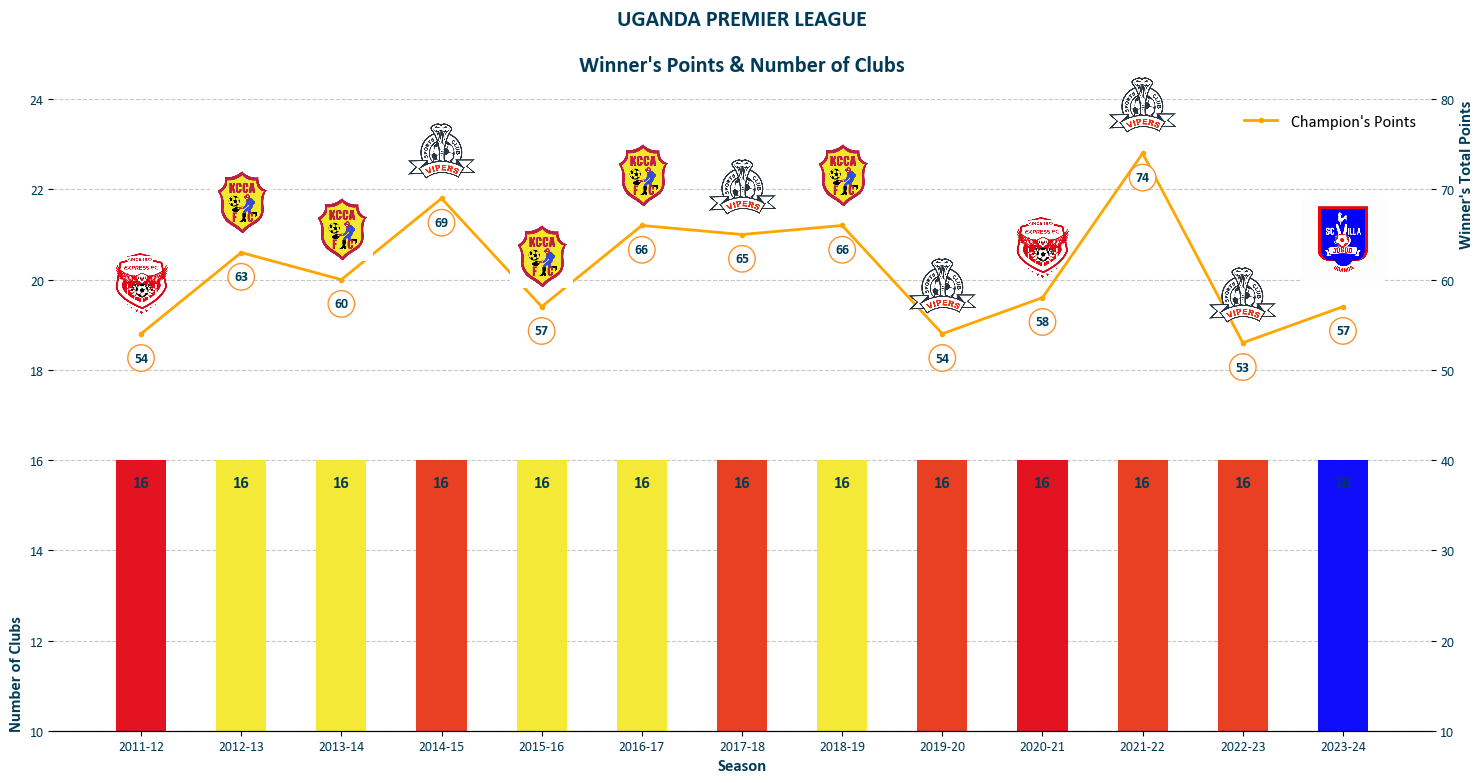

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Load the data
file_path = "C:\\Users\\Travail\\OneDrive\\Desktop\\FUFA\\Historical Data\\Copy of UPL Winners 2013-2023.xlsx"

# Read a specific sheet into a DataFrame
sheet_name = "Sheet1"  # Replace with the name of your sheet
df = pd.read_excel(file_path, sheet_name=sheet_name)

df=df[df['Season'] >= '2011-12']

df=df.fillna(0)  # Fill NaN values with 0
# Convert columns to appropriate data types 
df['Season'] = df['Season'].astype(str)
df[['Points','No of Teams']] = df[['Points','No of Teams']].astype(int)

# Set a modern font globally
plt.rcParams['font.family'] = 'Calibri' 
plt.rcParams['font.size'] = 12  # Set a default font size#
plt.rcParams['axes.titlesize'] = 16  # Set font size for titles
plt.rcParams['axes.labelsize'] = 12  # Set font size for axis labels
plt.rcParams['xtick.labelsize'] = 10  # Set font size for x-axis tick labels
plt.rcParams['ytick.labelsize'] = 10  # Set font size for y-axis tick labels

# Define team colors (Replace with actual colors)
team_colors = {
    'Express FC': '#E30615',
    'KCCA FC': '#F3E82B',
    'Vipers SC': '#E83618',
    'SC Villa': '#0200FC'
}

# Define paths to team logos (Ensure the filenames match exactly)
logo_folder = "C:\\Users\\Travail\\Downloads" 
team_logos = {
    team: os.path.join(logo_folder, f"{team.lower()}.png") for team in team_colors.keys()
}

# Create figure and axis
fig, ax1 = plt.subplots(figsize=(15, 8))

# Map bar colors based on the champion team
bar_colors = [team_colors[team] for team in df['Champion']]

# Plot bar graph for Teams Count with champion team colors
ax1.bar(df['Season'], df['No of Teams'], alpha=0.95, color=bar_colors, width=0.5, label="Number of Clubs", zorder=2)
ax1.set_ylabel("Number of Clubs", fontsize=12, fontweight='bold', color='#003b59',loc='bottom')

ax1.set_ylim(10, 24)  # Set y-axis range for bar graph
ax1.tick_params(axis='y', labelcolor='#003b59')

# Annotate bars with values inside the bars
for i, (season, teams) in enumerate(zip(df['Season'], df['No of Teams'])):
    ax1.text(i, teams - 0.5, str(teams), ha='center', va='center', color='#003b59', fontsize=12, fontweight='bold', zorder=3)

# Create a second Y-axis for the line graph
ax2 = ax1.twinx()
ax2.plot(df['Season'], df['Points'], color='orange', marker='.', linestyle='-', linewidth=2, label="Champion's Points", zorder=3)
ax2.set_ylabel("Winner's Total Points", color='#003b59', fontsize=12, fontweight='bold',loc='top')

ax2.set_ylim(10, 80)  # Set y-axis range for line graph
ax2.tick_params(axis='y', labelcolor='#003b59')

# Annotate points and add logos
for i, (season, points, team) in enumerate(zip(df['Season'], df['Points'], df['Champion'])):
    ax2.annotate(points, (season, points), textcoords="offset points", xytext=(0, -20), ha='center',
     color='#003b59', fontsize=10, fontweight='bold', zorder=4,
     bbox=dict(boxstyle="circle,pad=0.45", edgecolor='#FE912A', facecolor='white', linewidth=1))
    # Add logos for each team
    if team in team_logos:
        logo_path = team_logos[team]
        img = plt.imread(logo_path)
        imagebox = OffsetImage(img, zoom=0.15)  # Increase the zoom level for larger images
        ab = AnnotationBbox(imagebox, (i, points), frameon=False, box_alignment=(0.5, -0.3))
        ax2.add_artist(ab)
        

# Titles and labels
plt.title("UGANDA PREMIER LEAGUE\n\nWinner's Points & Number of Clubs", fontsize=16, fontweight='bold', pad=20,color='#003b59')
ax1.set_xlabel("Season", fontweight='bold',color='#003b59')

# Set x-ticks to show all seasons
ax1.set_xticks(df['Season'])
ax1.set_xticklabels(df['Season'], ha='center', fontsize=10,color='#003b59')

# Set grid for better readability
ax1.grid(axis='y', linestyle='--', alpha=0.7)


# Remove the top and side spines
ax1.spines['top'].set_visible(False)  # Remove the top spine
ax1.spines['right'].set_visible(False)  # Remove the right spine
ax1.spines['left'].set_visible(False)  # Remove the left spine (optional, if needed)

ax2.spines['top'].set_visible(False)  
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)  

# Remove the legend boundary

ax2.legend(loc='upper right', frameon=False)  # For the second axis

# Show plot
plt.tight_layout()
plt.show()


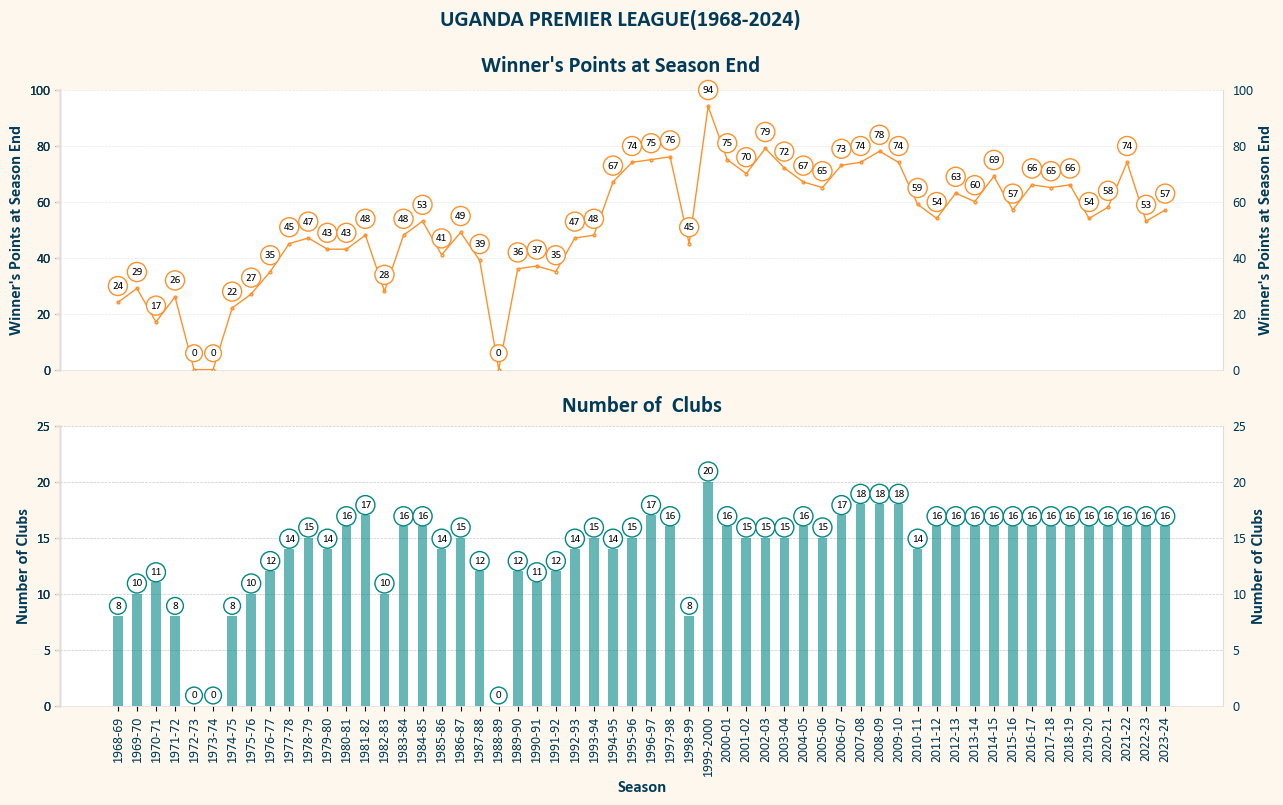

In [4]:
file_path = "C:\\Users\\Travail\\OneDrive\\Desktop\\FUFA\\Historical Data\\Copy of UPL Winners 2013-2023.xlsx"

# Read a specific sheet into a DataFrame
sheet_name = "Sheet1"  # Replace with the name of your sheet
df = pd.read_excel(file_path, sheet_name=sheet_name)

df=df.fillna(0)  # Fill NaN values with 0
# Convert columns to appropriate data types 
df['Season'] = df['Season'].astype(str)
df[['Points','No of Teams']] = df[['Points','No of Teams']].astype(int)

# Set a modern font globally
plt.rcParams['font.family'] = 'Calibri' 
plt.rcParams['font.size'] = 12  # Set a default font size#
plt.rcParams['axes.titlesize'] = 16  # Set font size for titles
plt.rcParams['axes.labelsize'] = 12  # Set font size for axis labels
plt.rcParams['xtick.labelsize'] = 10  # Set font size for x-axis tick labels
plt.rcParams['ytick.labelsize'] = 10  # Set font size for y-axis tick labels

fig,(ax1,ax2)=plt.subplots(2,1,sharex=True,figsize=(15, 8))
fig.subplots_adjust(hspace=0.2)  # Adjust space between subplots
fig.suptitle("UGANDA PREMIER LEAGUE(1968-2024) \n \n Winner's Points at Season End  ", color='#003b59', fontsize=16, fontweight='bold')
fig.patch.set_facecolor('#FEF7ED')  

ax1.plot(df['Season'], df['Points'], color='#FE912A', marker='o', linestyle='-',
 linewidth=1, 
 markersize=2,
 markerfacecolor='none',
 markeredgecolor='#FE912A',
 label="Champion's Points", zorder=3)
# ax1.set_facecolor('#FEF7ED')  # Set background color for the plot area

ax1.set_ylabel("Winner's Points at Season End", color='#003b59', fontsize=12, fontweight='bold')
ax1.yaxis.set_label_position("right")  # Set label position for the right y-axis
ax1.set_ylim(0, 100)  # Set y-axis range for line graph
ax1.tick_params(axis='y', labelcolor='#003B59')
ax1.yaxis.set_tick_params(labelleft=True,labelright=True,color='#e0dcdc')

ax1.secondary_yaxis('left').set_ylabel("Winner's Points at Season End", color='#003b59', fontsize=12, fontweight='bold')

ax1.spines['top'].set_visible(False)  
ax1.spines['right'].set_color('#E0DCDD')
ax1.spines['left'].set_color('#E0DCDD')
ax1.spines['bottom'].set_color('#E0DCDD')
ax1.spines['bottom'].set_linewidth(0.5)

ax1.tick_params(axis='x', which='both', bottom=False)  # Remove x-axis ticks

# ax1.set_title("Champion's Total Points at Season End", color='#003b59', fontsize=16, fontweight='bold', pad=20)
# Add subtle y-axis grid for ax1
ax1.grid(axis='y', linestyle='--', linewidth=0.5, color='#E0DCDD', alpha=0.7)

for i, txt in enumerate(df['Points']):
    ax1.annotate(txt, 
                 (df['Season'][i], df['Points'][i]),
                   textcoords="offset points", 
                   xytext=(0, 10), 
                   ha='center',
        fontsize=8,
        bbox=dict(boxstyle="circle,pad=0.35", edgecolor='#FE912A', facecolor='white', linewidth=1))

#Bar Graph for Number of Teams
ax2.bar(df['Season'], df['No of Teams'], alpha=0.6, color='#008785', width=0.5, label="Number of Teams", zorder=2)
# ax2.set_facecolor('#FEF7ED')  # Set background color for the plot area

#x-axis 
ax2.set_xlabel("Season", fontweight='bold',color='#003b59')
ax2.set_xticks(df['Season'])
ax2.set_xticklabels(df['Season'], rotation=90, ha='center', fontsize=10, color='#003b59')

#y-axis
ax2.set_ylabel("Number of Clubs", color='#003b59', fontsize=12, fontweight='bold')

# Set label position for both axes
ax2.yaxis.set_label_position("right")  # Set label position for the left y-axis
ax2.secondary_yaxis('left').set_ylabel("Number of Clubs", color='#003b59', fontsize=12,fontweight='bold')

ax2.set_ylim(0, 25)  # Set y-axis range for bar graph
ax2.tick_params(axis='y', labelcolor='#003b59')
ax2.yaxis.set_tick_params(labelleft=True,labelright=True,color='#e0dcdc')

# Add subtle y-axis grid for ax1
ax2.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.7)

ax2.spines['top'].set_visible(False)  
ax2.spines['right'].set_color('#E0DCDD')
ax2.spines['left'].set_color('#E0DCDD')
ax2.spines['bottom'].set_color('#E0DCDD')
ax2.spines['bottom'].set_linewidth(0.5)

ax2.set_title("Number of  Clubs", color='#003b59', fontsize=16, fontweight='bold', pad=10)

# Annotate values at the top of each bar
for i, value in enumerate(df['No of Teams']):
    ax2.text(
        i, value + 0.5, str(value),
        ha='center', va='bottom',
        fontsize=8,
        bbox=dict(boxstyle="circle,pad=0.35", edgecolor='#008785', facecolor='white', linewidth=1)
    )

plt.show()